### Questions

- drop iwn since it starts in 2006
- should we not start from [100]? why do we delete the first [100]?

## 2 CRSP Data and Monthly Panel Construction

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import wrds
import matplotlib.pyplot as plt
from dateutil.relativedelta import *
from pandas.tseries.offsets import *
from scipy import stats
from tqdm import tqdm

ModuleNotFoundError: No module named 'pandas'

###  2.1 WRDS and Data Querying

In [ ]:
db = wrds.Connection(wrds_username='rio_yoko', wrds_password='yokoyama0928')

Loading library list...
Done


### 2.2 CRSP and the Investable Universe

In [ ]:
def get_crsp_monthly_panel(db, start: str, end: str) -> pd.DataFrame:
    """
    Pull the CRSP monthly panel *with* security descriptors via a time-bounded
    join to msenames (since shrcd/exchcd live in the name-history tables).

    Filters (can be edited):
      - U.S. common stocks: shrcd in (10, 11)
      - Major exchanges   : exchcd in (1, 2, 3)  # NYSE, AMEX, NASDAQ

    Returns
    -------
    DataFrame with date, permno, prc, shrout, ret, retx, shrcd, exchcd,
    and a computed market cap (mktcap).
    """
    start_dt = pd.to_datetime(start)
    end_dt   = pd.to_datetime(end)
    # print('Fetching CRSP monthly data from WRDS...')
    # print(start_dt, end_dt)

    years = range(start_dt.year, end_dt.year + 1)
    frames = []

    for y in tqdm(years, desc="CRSP years"):
        # Restrict each SQL to one calendar year, clipped to [start, end]
        chunk_start = max(pd.Timestamp(f"{y}-01-01"), start_dt)
        chunk_end   = min(pd.Timestamp(f"{y}-12-31"), end_dt)

        q = f"""
        SELECT
            m.date,
            m.permno,
            m.permco,
            m.prc,
            m.shrout,
            m.ret,
            m.retx,
            n.shrcd,
            n.exchcd
        FROM crsp.msf AS m
        JOIN crsp.msenames AS n
          ON m.permno = n.permno
         AND m.date BETWEEN n.namedt AND COALESCE(n.nameendt, '9999-12-31') 
         -- A given stock (permno) can have multiple records in msenames over time: ticker changes, exchange moves, share code reclassifications, mergers.
        WHERE m.date BETWEEN '{chunk_start:%Y-%m-%d}' AND '{chunk_end:%Y-%m-%d}'
          AND n.shrcd IN (10, 11)    -- U.S. common shares
          AND n.exchcd IN (1, 2, 3)  -- NYSE, AMEX, NASDAQ
          AND m.prc    IS NOT NULL
          AND m.shrout IS NOT NULL
        ORDER BY m.date, m.permno;
        """

        frames.append(db.raw_sql(q))

    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

    # ---- Standardize dtypes and construct market cap ----
    if not df.empty:
        df["date"]   = pd.to_datetime(df["date"])
        df["prc"]    = pd.to_numeric(df["prc"], errors="coerce").abs()  # CRSP price may carry sign
        df["shrout"] = pd.to_numeric(df["shrout"], errors="coerce") * 1000.0  # in *thousands* of shares
        df["ret"]    = pd.to_numeric(df.get("ret", pd.Series()),   errors="coerce")
        df["retx"]   = pd.to_numeric(df.get("retx", pd.Series()),  errors="coerce")
        df["mktcap"] = df["prc"] * df["shrout"]

    return df


In [ ]:
def get_delistings(db, start: str, end: str) -> pd.DataFrame:
    """
    Pull delisting returns from CRSP delisting table.

    Returns
    -------
    DataFrame with permno, dlstdt (delisting date), dlret (delisting return).
    """
    q = f"""
    SELECT
        permno,
        dlstdt,
        dlret
    FROM crsp.msedelist
    WHERE dlstdt BETWEEN '{start}' AND '{end}'
      AND dlret IS NOT NULL
    ORDER BY permno, dlstdt;
    """

    df = db.raw_sql(q)

    if not df.empty:
        df["date"] = pd.to_datetime(df["dlstdt"])
        df["dlret"]  = pd.to_numeric(df["dlret"], errors="coerce")

    return df

###  2.3 Delisting Return Mitigation

$$r_\text{eff} = (1 + r_\text{CRSP}) \cdot (1 + r_\text{delist}) - 1$$

In [ ]:
def add_effective_returns(panel: pd.DataFrame, delist: pd.DataFrame) -> pd.DataFrame:
    out = panel.merge(delist, on=["permno", "date"], how="left")
    out['ret_eff'] = (1 + out['ret'].fillna(0)) * (1 + out['dlret'].fillna(0).fillna(0)) - 1
    return out

##  3 Mathematics and Index Construction


###  3.1 Market Capitalization and Stock Selection

Market capitalization for security $i$ on day $t$ is given by:

$$
\text{mktcap}_{i,t} = |prc_{i,t}| \times shrout_{i,t} \times 1000
$$

At each **reconstitution date**, the top $N$ securities by market capitalization are selected to form the index universe:

$$
S_t = \{ permno_1, \ldots, permno_N \}
$$

This step refreshes the index membership and differs from simple **rebalancing**, where the portfolio weights are adjusted without changing constituent securities.

###  3.2 Reconstitution vs. Rebalancing

Reconstitution refreshes the index membership at each period using information as of t−1.
 Rebalancing adjusts the weights among present constituents based on lagged market cap
 or prices, but does not alter the set of stocks except at reconstitution

### 3.3 Index Weighting Schemes


**Equal-Weighted (EW):**

$$
w_{i,t-1}^{(EW)} = \frac{1}{N}
$$

$$
R_t^{(EW)} = \sum_{i \in S_t} w_{i,t-1}^{(EW)} r_{i,t}
$$


**Value-Weighted (VW):**

$$
w_{i,t-1}^{(VW)} = \frac{\text{mktcap}_{i,t-1}}{\sum_{j \in S_t} \text{mktcap}_{j,t-1}}
$$

$$
R_t^{(VW)} = \sum_{i \in S_t} w_{i,t-1}^{(VW)} r_{i,t}
$$


**Price-Weighted (PW):**

$$
w_{i,t-1}^{(PW)} = \frac{|prc_{i,t-1}|}{\sum_{j \in S_t} |prc_{j,t-1}|}
$$

$$
R_t^{(PW)} = \sum_{i \in S_t} w_{i,t-1}^{(PW)} r_{i,t}
$$


The index levels are then updated by compounding previous levels by these returns:

$$
L_t = L_{t-1}(1 + R_t), \quad L_0 = 100
$$


### 3.4 Monthly Index Calculation Loop

* Identify adjacent months: For each period t, use information available at t−1 (the
 preceding month) to define the investable universe and compute portfolio weights.
 This ensures all rebalancing and reconstitution decisions are made based solely on
 observable, non-forward-looking data, thereby avoiding look-ahead bias.

* Filter and select Top-N constituents: At month t−1, rank all eligible securities
 by market capitalization and select the top N as index constituents for month t. Their
 respective market caps and prices from t − 1 inform weight assignment.

* Match holdings and returns: For continuity, ensure that only securities present
 in both t − 1 and t are included in the index calculation for the holding period.
 Securities that delist between months have their final returns properly incorporated
 via the ret eff (effective return), which includes delisting returns.

* Calculate gross returns for each weighting scheme: For the chosen set, compute
 the aggregate index return as a gross multiple:
 1. Equal-weighted: arithmetic mean of each constituent’s gross return (1+ret eff).
 2. Value-weighted: weighted mean, using t-1 market cap proportions.
 3. Price-weighted: weighted mean, using t-1 price proportions.

* Compound index levels: Multiply the previous index level by the gross return to
 obtain the new level for month t. This is repeated for each weighting scheme, forming
 complete time series of index evolution.

* Handle missing or incomplete data: If data for a month is missing or insufficient
 (e.g., due to delistings or incomplete records), the index simply carries forward its last
 computed level, maintaining time series integrity

In [ ]:
def build_topn_indexes(panel: pd.DataFrame, top_n: int) -> pd.DataFrame:
    """
    Construct Equal-, Value-, and Price-Weighted index levels (base=100).

    Methodology reminder:
    - At month t, choose constituents and weights from t-1 information.
    - Grow index from t-1 to t using ret_eff (includes delistings).

    Returns
    -------
    DataFrame with three columns (EW, VW, PW) indexed by month t.
    """

    # Organize by month for quick lookup
    panel = panel.sort_values(['date', 'permno'])
    months = sorted(panel['date'].unique())
    by_month = {d: g for d, g in panel.groupby('date')}

    ew_level = [100.0]
    vw_level = [100.0]
    pw_level = [100.0]

    # Loop from 2nd available month; need t-1 and t
    for i in tqdm(range(1, len(months)), desc="Index Calculation Progress"):
        t_1, t = months[i-1], months[i]
        g_t1 = by_month[t_1].dropna(subset=['mktcap', 'prc'])
        g_t  = by_month[t]

        if g_t1.empty or g_t.empty:
            # carry forward if missing data
            ew_level.append(ew_level[-1])
            vw_level.append(vw_level[-1])
            pw_level.append(pw_level[-1])
            continue

        # Top-N by market cap at t-1
        chosen = g_t1.sort_values('mktcap', ascending=False).head(top_n).set_index('permno')

        # Ensure we have returns at t for the chosen PERMNOs
        g_t = g_t.set_index('permno')
        common = chosen.index.intersection(g_t.index)
        if len(common) == 0:
            ew_level.append(ew_level[-1])
            vw_level.append(vw_level[-1])
            pw_level.append(pw_level[-1])
            continue

        r_t = g_t.loc[common, 'ret_eff'].astype(float)

        # Equal-Weighted: average of gross returns
        r_t_ew = r_t.dropna()
        ew_gross = (1.0 + r_t_ew).mean() if not r_t_ew.empty else 1.0

        # Value-Weighted: weights from t-1 market cap
        w_vw = chosen.loc[common, 'mktcap'].astype(float)
        mask_vw = r_t.notna()
        w_vw = w_vw.loc[mask_vw]
        r_vw = r_t.loc[mask_vw]
        if r_vw.empty or w_vw.sum() <= 0:
            vw_gross = 1.0
        else:
            w_vw = w_vw / w_vw.sum()
            vw_gross = ((1.0 + r_vw) * w_vw).sum()

        # Price-Weighted: weights from t-1 price
        w_pw = chosen.loc[common, 'prc'].astype(float)
        mask_pw = r_t.notna()
        w_pw = w_pw.loc[mask_pw]
        r_pw = r_t.loc[mask_pw]
        if r_pw.empty or w_pw.sum() <= 0:
            pw_gross = 1.0
        else:
            w_pw = w_pw / w_pw.sum()
            pw_gross = ((1.0 + r_pw) * w_pw).sum()

        # Compound index levels
        ew_level.append(ew_level[-1] * float(ew_gross))
        vw_level.append(vw_level[-1] * float(vw_gross))
        pw_level.append(pw_level[-1] * float(pw_gross))

    # Convert to tidy DataFrame indexed by month t
    idx_months = pd.to_datetime(months[1:])
    ew = pd.Series(ew_level[1:], index=idx_months, name='Equal-Weighted')
    vw = pd.Series(vw_level[1:], index=idx_months, name='Value-Weighted')
    pw = pd.Series(pw_level[1:], index=idx_months, name='Price-Weighted')

    return pd.concat([ew, vw, pw], axis=1)


### 4 Benchmark ETF Indexes and Log-Return Analytics


In [ ]:
def pick_permno_for_ticker(db, ticker: str, as_of: pd.Timestamp) -> int | None:
    """
    Given a ticker and a date, pick the most appropriate PERMNO.

    Criteria (in order):
    1) Active on as_of date (namedt <= as_of <= nameendt or nameendt is null)
    2) If multiple, pick the one with the longest active history (namedt earliest)
    3) If still multiple, pick the one with the highest average daily trading volume over the past year

    Returns
    -------
    Selected PERMNO or None if no valid PERMNO found.
    """
    q = f"""
    SELECT
        n.permno,
        n.namedt,
        n.nameendt
    FROM crsp.msenames AS n
    WHERE n.ticker = '{ticker}'
      AND n.namedt <= '{as_of:%Y-%m-%d}'
      -- AND (n.nameendt >= '{as_of:%Y-%m-%d}' OR n.nameendt IS NULL)
    ORDER BY n.namedt;
    """

    df = db.raw_sql(q)

    # print(df)

    if df.empty:
        return None

    # If only one candidate, return it
    if len(df) == 1:
        return int(df.iloc[0]['permno'])

    # Multiple candidates: pick the one with the longest history
    df['namedt'] = pd.to_datetime(df['namedt'])
    df['nameendt'] = pd.to_datetime(df['nameendt']).fillna(pd.Timestamp('9999-12-31'))
    df['history_length'] = (df['nameendt'] - df['namedt']).dt.days

    max_history = df['history_length'].max()
    candidates = df[df['history_length'] == max_history]

    return int(candidates.iloc[0]['permno'])

# check if the functions works correctly
# print(pick_permno_for_ticker(db, 'SPY', pd.Timestamp('2020-01-15')))
    


In [ ]:
def get_etf_index(db, permno: int, start: str, end: str, label: str) -> pd.Series:
    """
    Build a 100-based index level for a single security by compounding monthly returns.
    Useful for quick benchmark overlays.

    Parameters
    ----------
    db : wrds.Connection
    permno : int
    start, end : 'YYYY-MM-DD' strings (inclusive)
    label : name for the returned Series
    """
    q = f"""
        SELECT date, ret
        FROM crsp.msf
        WHERE permno = {permno}
          AND date BETWEEN '{start}' AND '{end}'
        ORDER BY date;
    """

    d = db.raw_sql(q)
    d['date'] = pd.to_datetime(d['date'])
    d = d.sort_values('date')
    d['ret'] = pd.to_numeric(d['ret'], errors='coerce').fillna(0.0)

    idx = (1.0 + d['ret']).cumprod() * 100.0
    idx.index = d['date']
    idx.name = label
    return idx

### 4.1 Log Return Correlations

In [ ]:
def align_and_corr(levels: list[pd.Series]) -> pd.DataFrame:
    """
    Align multiple index-level Series on their common dates and
    return the correlation matrix of their log returns.
    """
    common = set(levels[0].index)
    for s in levels[1:]:
        # find intersection of dates
        common &= set(s.index)
    common = sorted(common)

    aligned = [s.loc[common] for s in levels]
    panel = pd.concat(aligned, axis=1)

    log_ret = np.log(panel / panel.shift(1)).dropna(how='any')
    return log_ret.corr()

In [ ]:
def show_corr_table(corr: pd.DataFrame):
    """
    Display a correlation matrix with color coding.
    """
    fig, ax = plt.subplots(figsize=(6, 5))
    cax = ax.matshow(corr, cmap='coolwarm', vmin=0.6, vmax=1)
    fig.colorbar(cax)

    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha='left')
    ax.set_yticklabels(corr.columns)

    for (i, j), val in np.ndenumerate(corr.values):
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

    plt.title("Correlation Matrix of Log Returns", pad=20)
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_indexes(custom_df: pd.DataFrame, etf_map: dict[str, pd.Series], top_n: int):
    """
    Plot custom indexes along with ETF benchmarks.
    """
    plt.figure(figsize=(12, 6))

    # Plot custom indexes
    for col in custom_df.columns:
        plt.plot(custom_df.index, custom_df[col], label=col)

    # Plot ETF benchmarks
    for label, series in etf_map.items():
        plt.plot(series.index, series, label=f'{label} (ETF)', linestyle='--')

    etf_names = ', '.join(etf_map.keys())

    plt.title(f"Top {top_n} Indexes with {etf_names} Benchmarks")
    plt.xlabel("Date")
    plt.ylabel("Index Level (Base=100)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

###  5 Putting it Together


In [ ]:
START_DATE = '2000-01-01'
END_DATE = '2020-12-31'
TOP_N = 2000

START_TS = pd.to_datetime(START_DATE)
END_TS = pd.to_datetime(END_DATE)


[Step 1/5] Pulling CRSP MSF panel with universe filters 


CRSP years:   0%|          | 0/21 [00:00<?, ?it/s]

CRSP years: 100%|██████████| 21/21 [00:26<00:00,  1.28s/it]


Rows pulled: 1,096,046

[Step 2/5] Merging delisting returns and computing ret_eff 

[Step 3/5] Building Equal-, Value-, and Price-Weighted Top-N indexes 


Index Calculation Progress: 100%|██████████| 251/251 [00:01<00:00, 243.48it/s]



[Step 4/5] Getting ETF benchmarks 

[Step 5/5] Plotting and computing correlations 



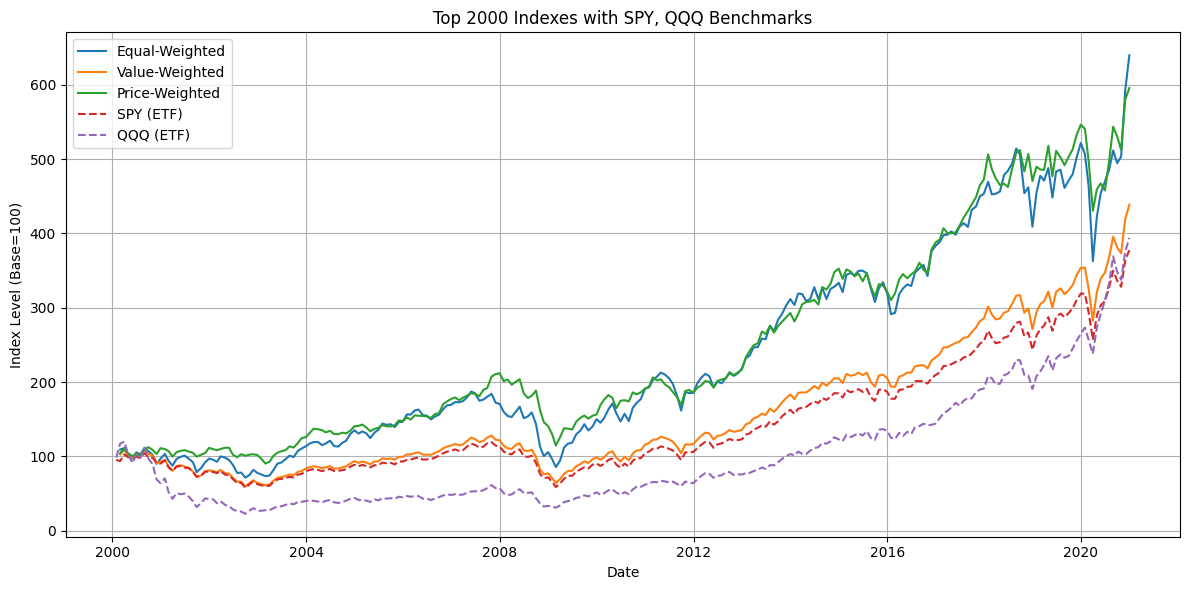

Correlation Matrix (monthly log returns):
                 Equal-Weighted  Value-Weighted  Price-Weighted  SPY (ETF)  \
Equal-Weighted        1.000000        0.949898        0.780537   0.918802   
Value-Weighted        0.949898        1.000000        0.795330   0.991437   
Price-Weighted        0.780537        0.795330        1.000000   0.776297   
SPY (ETF)             0.918802        0.991437        0.776297   1.000000   
QQQ (ETF)             0.807942        0.869336        0.586555   0.848501   

                QQQ (ETF)  
Equal-Weighted   0.807942  
Value-Weighted   0.869336  
Price-Weighted   0.586555  
SPY (ETF)        0.848501  
QQQ (ETF)        1.000000  


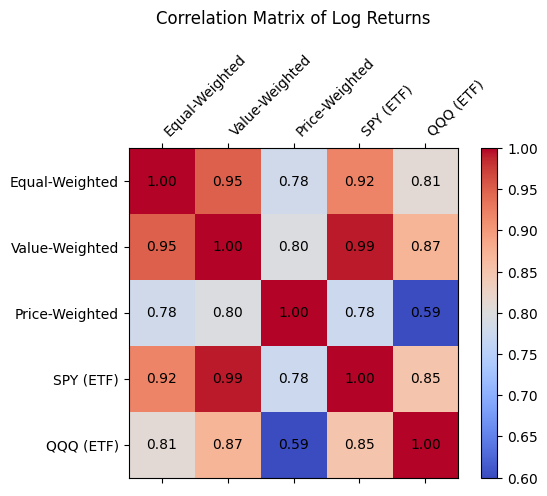

In [ ]:
# 1) Pull the panel and delistings, then compute effective returns
print("\n[Step 1/5] Pulling CRSP MSF panel with universe filters ")
panel = get_crsp_monthly_panel(db, START_DATE, END_DATE)
print(f"Rows pulled: {len(panel):,}")

print("\n[Step 2/5] Merging delisting returns and computing ret_eff ")
delist = get_delistings(db, START_DATE, END_DATE)
panel = add_effective_returns(panel, delist)


# 2) Build the custom Top-N indexes
print("\n[Step 3/5] Building Equal-, Value-, and Price-Weighted Top-N indexes ")
custom_levels = build_topn_indexes(panel, TOP_N)


# 3) ETF benchmarks (SPY, IWM, QQQ) robust permno selection around START_DATE
print("\n[Step 4/5] Getting ETF benchmarks ")
etf_tickers = ['SPY', 'IWM', 'QQQ']
etf_series = {}
for tkr in etf_tickers:
    pno = pick_permno_for_ticker(db, tkr, START_TS)
    if pno is None:
        print(f"Warning: no PERMNO found for {tkr} near {START_DATE}. Skipping.")
        continue
    etf_series[tkr] = get_etf_index(db, pno, START_DATE, END_DATE, f"{tkr} (ETF)")


# 4) Plot the results
print("\n[Step 5/5] Plotting and computing correlations \n")
plot_indexes(custom_df=custom_levels, etf_map=etf_series, top_n=TOP_N)


# Align and compute correlation (monthly log returns) across all available series
all_series = [custom_levels[c] for c in custom_levels.columns] + \
             [s for s in etf_series.values()]

corr_mat = align_and_corr(all_series)
print("Correlation Matrix (monthly log returns):\n", corr_mat)
show_corr_table(corr_mat)


###  6 Visualization and Analysis


In [ ]:
# Close the WRDS connection
db.close()

###  7 Best Practices and Further Considerations

* Employ annual or manageable time-windowed queries to mitigate memory issues.


### 8 Lessons from Custom Index Construction

*  look-ahead bias and survivorship bias. 
* Using lagged (t-1) market caps and prices for constituent selection and weighting effectively removes look-ahead bias—reflecting the true information set available
 to investors at portfolio formation.
* Survivorship bias is addressed by integrating delisting returns, ensuring that firms exiting
 the exchange do not silently vanish, skewing results positively. This nuanced treatment of
 delisting return data is critical for credible backtests and return measurement over longer
 horizons.